In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap  
from sklearn.metrics import roc_curve, auc, accuracy_score, recall_score, confusion_matrix, matthews_corrcoef

In [2]:
# Define features (post-correlation drop) and target

# 1. Load the dataset from the CSV file
df = pd.read_csv('data/thresholded_image_clinical_features.csv')

# 2. Define target and features
# (Change 'HRD_Proxy' if you named the column something else when saving the CSV)
target_col = 'HRD_Proxy' 

y = df[target_col]
X = df.drop(columns=[target_col])

In [3]:
# 3. Initialize Random Forest and Stratified 10-Fold CV
rf = RandomForestClassifier(n_estimators=100, random_state=42)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# List to store feature importances for each fold
importances_list = []

# 4. Run 10-Fold Cross-Validation
for train_idx, test_idx in skf.split(X, y):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    rf.fit(X_train, y_train)
    importances_list.append(rf.feature_importances_)


# Convert list to an array to easily calculate mean and std across folds
importances_array = np.array(importances_list)
mean_importances = np.mean(importances_array, axis=0)
std_importances = np.std(importances_array, axis=0)

# 5. Consolidate into a DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean_Importance': mean_importances,
    'Std_Importance': std_importances
})

# Get the Top 15 features sorted by Mean Importance
top_15_df = feature_importance_df.sort_values(by='Mean_Importance', ascending=False).head(15)


In [4]:
# 1. Subset data to ONLY the top 15 features
# Extract list for your clustermap later
top_15_features = top_15_df['Feature'].tolist()
# 1. Subset data and setup identical CV/Model
X_top = X[top_15_features]
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
rf_top = RandomForestClassifier(n_estimators=100, random_state=42)

# Lists to store fold metrics
accuracies, sensitivities, specificities, mccs = [], [], [], []

# 2. Run CV Loop
for train_idx, test_idx in cv.split(X_top, y):
    X_train, y_train = X_top.iloc[train_idx], y.iloc[train_idx]
    X_test, y_test = X_top.iloc[test_idx], y.iloc[test_idx]
    
    rf_top.fit(X_train, y_train)
    y_pred = rf_top.predict(X_test)
    
    # Accuracy
    accuracies.append(accuracy_score(y_test, y_pred))
    
    # Sensitivity (Recall / True Positive Rate)
    sensitivities.append(recall_score(y_test, y_pred))
    
    # Specificity (True Negative Rate) requires the confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificities.append(tn / (tn + fp))
    
    # Matthew's Correlation Coefficient
    mccs.append(matthews_corrcoef(y_test, y_pred))

# 3. Calculate Mean and Std
metrics_data = [
    ("Accuracy", np.mean(accuracies), np.std(accuracies)),
    ("Sensitivity", np.mean(sensitivities), np.std(sensitivities)),
    ("Specificity", np.mean(specificities), np.std(specificities)),
    ("Matthew's Corr Coeff", np.mean(mccs), np.std(mccs))
]

# 4. Print directly as a Markdown Table
print("| Metric | Mean ± SD |")
print("| :--- | :--- |")
for name, mean_val, std_val in metrics_data:
    print(f"| {name} | {mean_val:.3f} ± {std_val:.3f} |")

| Metric | Mean ± SD |
| :--- | :--- |
| Accuracy | 0.810 ± 0.011 |
| Sensitivity | 0.032 ± 0.032 |
| Specificity | 0.984 ± 0.012 |
| Matthew's Corr Coeff | 0.043 ± 0.096 |


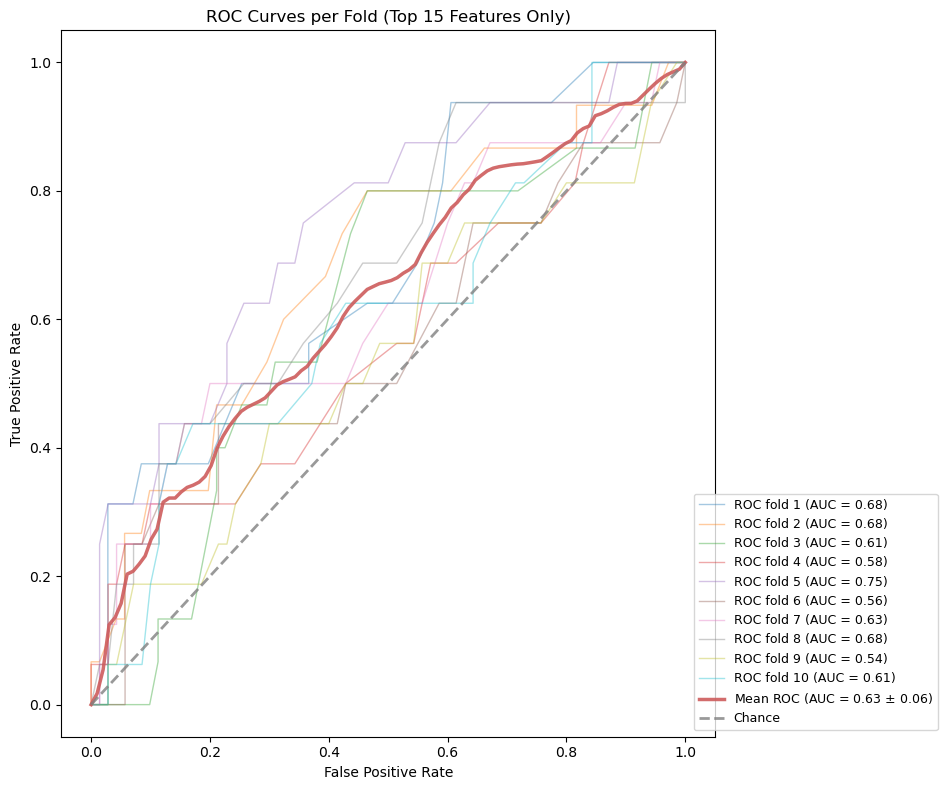

In [16]:
# roc cuvres

# 1. Subset data to ONLY the top 15 features
X_top = X[top_15_features]

# 2. Re-initialize the EXACT same CV splits and a new RF model
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
rf_top = RandomForestClassifier(n_estimators=100, random_state=42)

# 3. Setup the ROC plot
fig, ax = plt.subplots(figsize=(10, 8))

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

# 4. Loop through the folds, train, predict probabilities, and plot
for fold, (train_idx, test_idx) in enumerate(cv.split(X_top, y)):
    # Train
    rf_top.fit(X_top.iloc[train_idx], y.iloc[train_idx])
    
    # Predict probabilities for the positive class (1)
    y_prob = rf_top.predict_proba(X_top.iloc[test_idx])[:, 1]
    
    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y.iloc[test_idx], y_prob)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    
    # Interpolate to get a smooth mean curve later
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    
    # Plot this specific fold's ROC curve (lightly colored)
    ax.plot(fpr, tpr, lw=1, alpha=0.4, 
            label=f"ROC fold {fold + 1} (AUC = {roc_auc:.2f})")

# 5. Plot the Mean ROC Curve
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

ax.plot(mean_fpr, mean_tpr, color='indianred',
        label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
        lw=2.5, alpha=0.9)

# Plot the chance diagonal (50/50 guess)
ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='gray', label='Chance', alpha=0.8)

# Formatting
ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
       title="ROC Curves per Fold (Top 15 Features Only)",
       xlabel="False Positive Rate",
       ylabel="True Positive Rate")
ax.legend(loc="lower right", fontsize=9, bbox_to_anchor=(1.35, 0))

plt.tight_layout()
plt.savefig('results/roc_curves_top_15_features.png', dpi=300, bbox_inches='tight')
plt.show()

## Visualization

## random forest importance

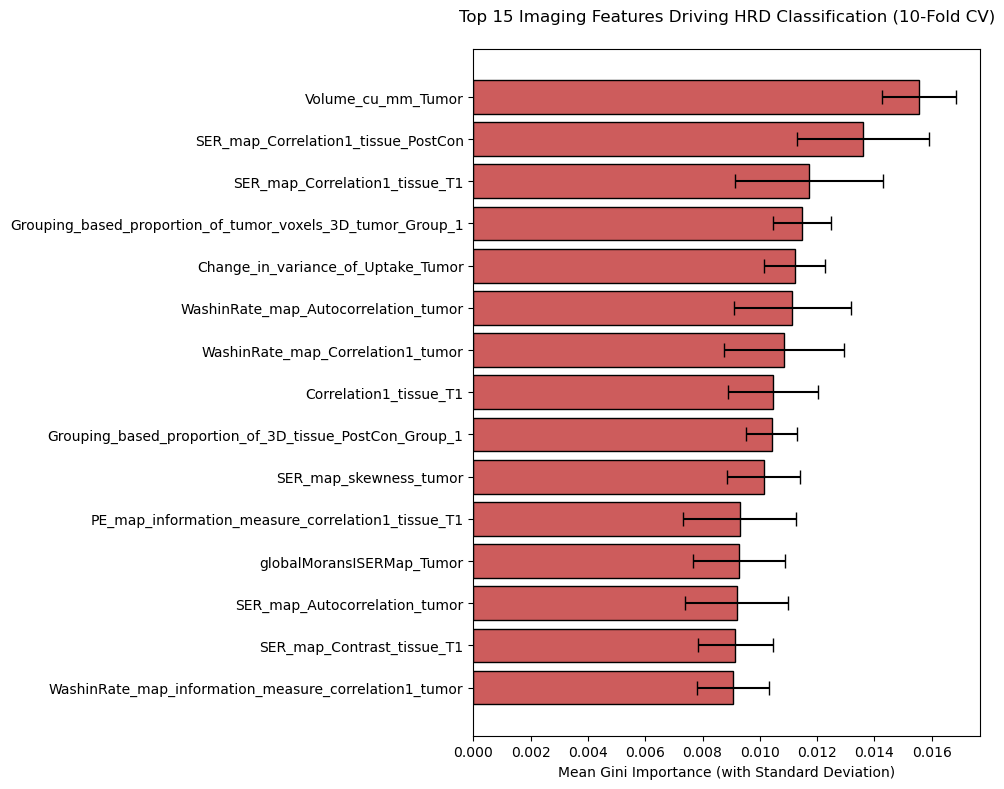

In [15]:


# 6. Plotting the results
plt.figure(figsize=(10, 8))

# Matplotlib builds horizontal bars from the bottom up. 
# We reverse the order ([::-1]) so the #1 most important feature is plotted at the very top.
top_15_df_plot = top_15_df.iloc[::-1]

plt.barh(
    top_15_df_plot['Feature'], 
    top_15_df_plot['Mean_Importance'], 
    xerr=top_15_df_plot['Std_Importance'], 
    capsize=5,
    color='indianred', # Kept red to match your proxy label colors from earlier!
    edgecolor='black'
)

plt.xlabel('Mean Gini Importance (with Standard Deviation)')
plt.title('Top 15 Imaging Features Driving HRD Classification (10-Fold CV)', pad=20)
plt.tight_layout()
f = plt.gcf()
f.savefig('results/top_15_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()



## clustering 

/Users/ariellejoasil/opt/anaconda3/envs/py312/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


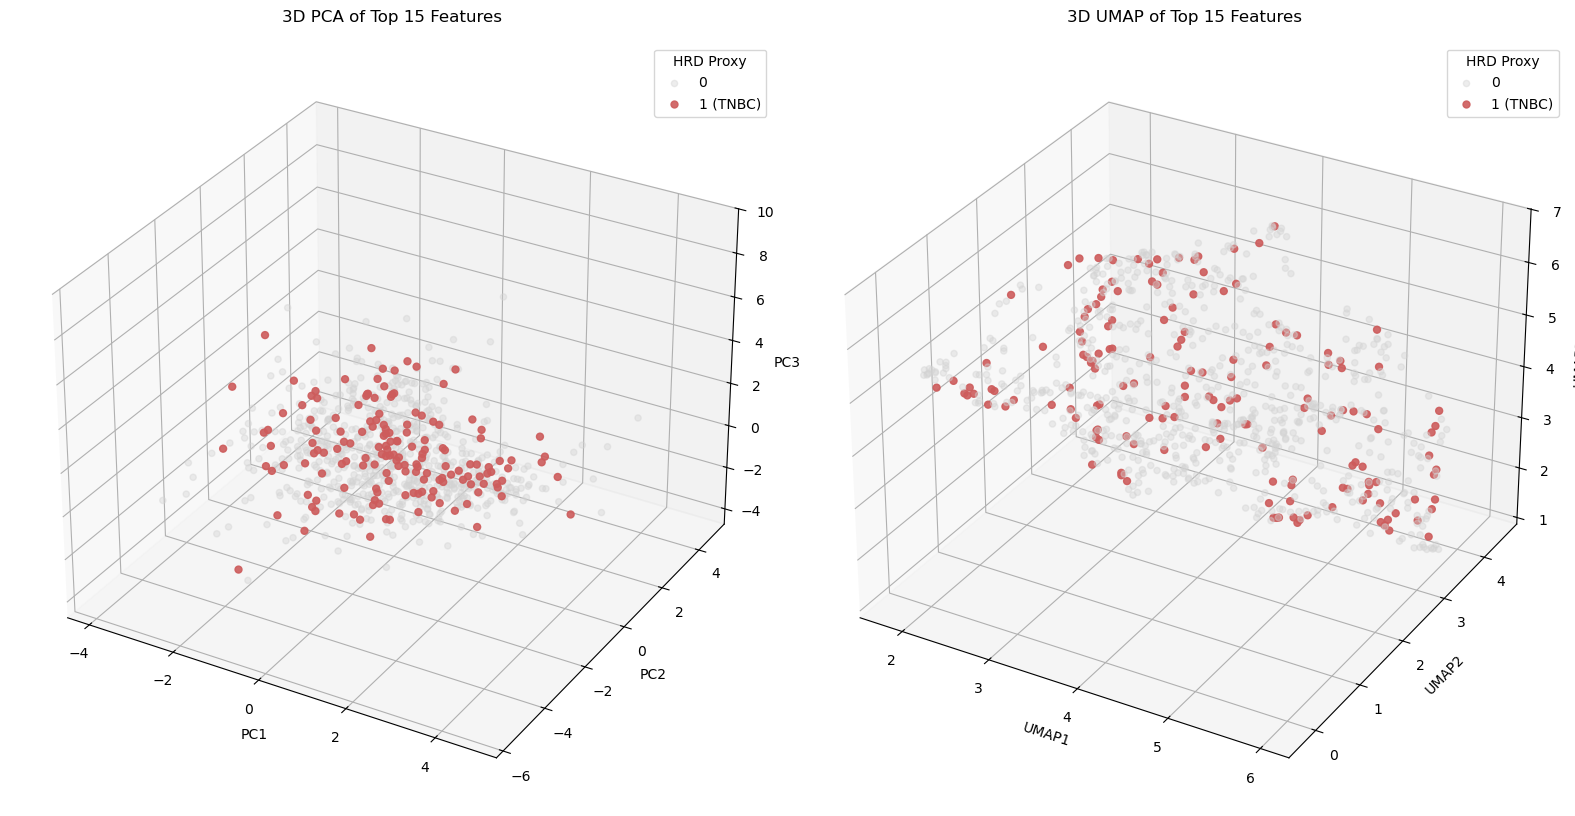

In [12]:


# 1. Subset your data to ONLY the top 15 features we just found
X_top = X[top_15_features]

# 2. Scale the data (CRITICAL for PCA and UMAP)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_top)

# 1. Extract the raw values for safe boolean indexing
y_vals = y.values

# 2. Run PCA with 3 components
pca_3d = PCA(n_components=3, random_state=42)
pca_result_3d = pca_3d.fit_transform(X_scaled)

# 3. Run UMAP with 3 components
reducer_3d = umap.UMAP(n_components=3, random_state=42)
umap_result_3d = reducer_3d.fit_transform(X_scaled)

# 4. Setup the 3D figures side-by-side
fig = plt.figure(figsize=(16, 8))

# --- 3D PCA Plot ---
ax1 = fig.add_subplot(121, projection='3d')
# Plot class 0 (Other)
ax1.scatter(pca_result_3d[y_vals==0, 0], pca_result_3d[y_vals==0, 1], pca_result_3d[y_vals==0, 2], 
            c='lightgray', label='0', alpha=0.4, s=20)
# Plot class 1 (TNBC / HRD Proxy)
ax1.scatter(pca_result_3d[y_vals==1, 0], pca_result_3d[y_vals==1, 1], pca_result_3d[y_vals==1, 2], 
            c='indianred', label='1 (TNBC)', alpha=0.9, s=25)

ax1.set_title('3D PCA of Top 15 Features', pad=15)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')
ax1.legend(title='HRD Proxy')

# --- 3D UMAP Plot ---
ax2 = fig.add_subplot(122, projection='3d')
# Plot class 0 (Other)
ax2.scatter(umap_result_3d[y_vals==0, 0], umap_result_3d[y_vals==0, 1], umap_result_3d[y_vals==0, 2], 
            c='lightgray', label='0', alpha=0.4, s=20)
# Plot class 1 (TNBC / HRD Proxy)
ax2.scatter(umap_result_3d[y_vals==1, 0], umap_result_3d[y_vals==1, 1], umap_result_3d[y_vals==1, 2], 
            c='indianred', label='1 (TNBC)', alpha=0.9, s=25)

ax2.set_title('3D UMAP of Top 15 Features', pad=15)
ax2.set_xlabel('UMAP1')
ax2.set_ylabel('UMAP2')
ax2.set_zlabel('UMAP3')
ax2.legend(title='HRD Proxy')

plt.tight_layout()
plt.show()
fig.savefig('results/3D_PCA_UMAP_top_15_features.png', dpi=300, bbox_inches='tight')

/Users/ariellejoasil/opt/anaconda3/envs/py312/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/ariellejoasil/opt/anaconda3/envs/py312/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


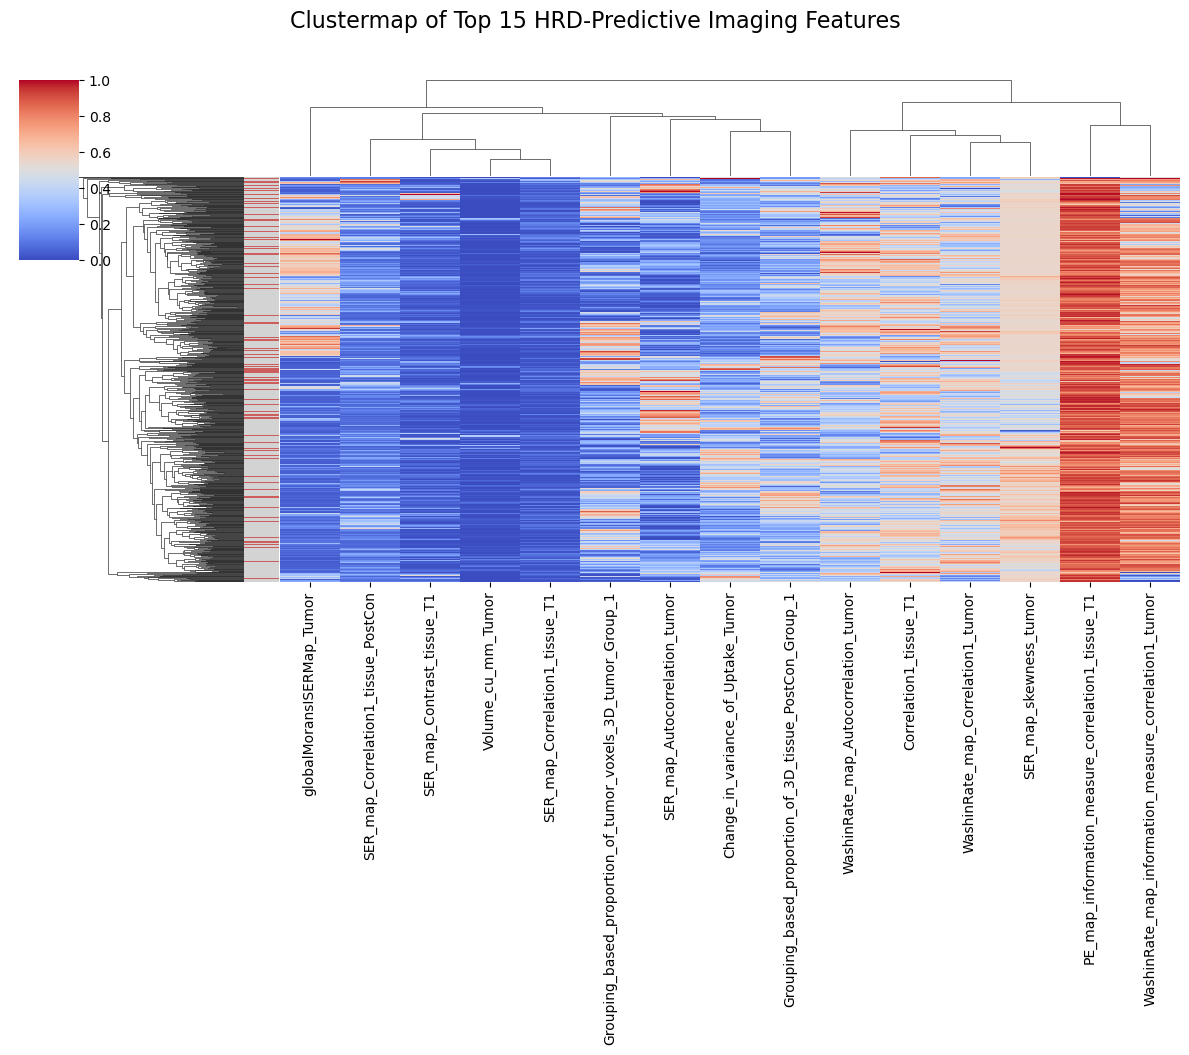

In [10]:


# 1. Subset the data to ONLY the Top 15 Features
X_top = X[top_15_features]

# 2. Create the color mapping for the HRD Proxy labels (Target)
# 0 (Other) = lightgray, 1 (Triple Negative) = indianred to match your other plots
lut = {0: 'lightgray', 1: 'indianred'}
row_colors = y.map(lut)

# 3. Generate the Clustermap
g = sns.clustermap(
    X_top,
    row_colors=row_colors.values,
    cmap='coolwarm',
    standard_scale=1, # Normalizes columns so they share the same color scale
    figsize=(12, 10),
    xticklabels=True, # Keep feature names visible!
    yticklabels=False # Hide patient index numbers to keep it clean
)

# 4. Add the Title and adjust layout
g.fig.suptitle('Clustermap of Top 15 HRD-Predictive Imaging Features', y=1.05, fontsize=16)

plt.show()
g.savefig('results/clustermap_top_15_features.png', dpi=300, bbox_inches='tight')